## Env Check

In [1]:
import sys
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Compiled Version: {torch.version.cuda}")
print(f"CUDA Available: {torch.cuda.is_available()}")

import logging
import os

# Suppress PyTorch compiler and Triton verbosity
os.environ["TORCH_LOGS"] = "-all"

for logger_name in ["torch", "torch._dynamo", "torch._inductor", "triton"]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

# Mute the filelock library explicitly
logging.getLogger("filelock").setLevel(logging.WARNING)

# Mute standard PyTorch and Triton loggers
logging.getLogger("torch").setLevel(logging.WARNING)
logging.getLogger("triton").setLevel(logging.WARNING)

# Stop third-party loggers from passing INFO messages to the root logger
for logger_name in ["filelock", "triton", "torch", "torch._inductor", "torch._dynamo"]:
    log = logging.getLogger(logger_name)
    log.setLevel(logging.WARNING)
    log.propagate = False
    
# Root logger: without this, level defaults to WARNING with no handler and
# every logging.info() in the training loop is silently discarded.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,          # override any handler a library installed first
)
logging.info("logging configured")   # if this does not print, nothing else will

execution_device = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch Version: 2.0.1+cu117
CUDA Compiled Version: 11.7
CUDA Available: True
2026-08-20 12:30:47,852 | INFO | logging configured


## Data Generator

In [2]:
import torch
import numpy as np
import logging
import os

DATA_SEED = 1234
DATA_CACHE = "dataset_v2.pt"

RHO_MIN, RHO_MAX = 500.0, 20000.0          # ohm-cm, realistic soil range
LOG_RHO_MIN, LOG_RHO_MAX = np.log10(RHO_MIN), np.log10(RHO_MAX)

def soil_to_log_rho(soil_prof):
    """Normalized soil profile in [0,1] -> log10(rho) in [log10(500), log10(20000)].
    Interpolation happens in LOG space because gamma ~ 1/sigma ~ rho spans 1.6
    decades; linear interpolation of rho itself would bias toward high values."""
    return LOG_RHO_MIN + soil_prof * (LOG_RHO_MAX - LOG_RHO_MIN)


def interp_profile(prof, x_query):
    """Linear interpolation of a [B,P] profile onto x_query in [0,1].

    prof     : [B, P]  values at P equally spaced nodes spanning x in [0,1]
    x_query  : [N]     query points in [0,1]
    returns  : [B, N]
    """
    B, P = prof.shape
    x_query = x_query.to(prof.device)
    xs = x_query.clamp(0.0, 1.0) * (P - 1)          # [N] in [0, P-1]
    i0 = xs.floor().long().clamp(0, P - 2)          # [N]
    frac = (xs - i0.float()).unsqueeze(0)           # [1,N]
    lo = prof[:, i0]                                # [B,N]
    hi = prof[:, i0 + 1]                            # [B,N]
    return lo + frac * (hi - lo)


def gamma_of_x(soil_prof, x_query, phys):
    """Per-sample, per-x charge-coupling coefficient.

    gamma = n*F*D*C_bulk / sigma,  sigma = 100/rho_ohm_cm
    Returns [B, N] matching x_query.
    NOTE: uses the scalar phys["C_bulk"]. Once C_bulk becomes a function of x
    (from the fluid profile), this must take the LOCAL C_bulk(x) instead --
    gamma is proportional to it."""
    log_rho = soil_to_log_rho(interp_profile(soil_prof, x_query))   # [B,N]
    rho = torch.pow(10.0, log_rho)
    sigma = 100.0 / rho
    return (phys["n_electrons"] * phys["F"] * phys["D_global"] * phys["C_bulk"]) / sigma


class API5LDataGenerator:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.wt_min, self.wt_max = 0.25, 1.0
        self.od_min, self.od_max = 4.0, 48.0

    def generate_grf_profiles(self, points, length_scale=0.2):
        x = np.linspace(0, 1, points)
        X, Y = np.meshgrid(x, x)
        cov = np.exp(-0.5 * ((X - Y) / length_scale) ** 2) + 1e-6 * np.eye(points)
        L = np.linalg.cholesky(cov)
        z = np.random.randn(self.batch_size, points)
        prof = 1 / (1 + np.exp(-(z @ L.T)))
        return torch.tensor(prof, dtype=torch.float32)

    def generate_api5l_metadata(self):
        real_wt = torch.FloatTensor(self.batch_size).uniform_(self.wt_min, self.wt_max)
        real_od = torch.FloatTensor(self.batch_size).uniform_(self.od_min, self.od_max)
        yolo_defect_score = torch.FloatTensor(self.batch_size).uniform_(0.0, 1.0)

        norm_wt = (real_wt - self.wt_min) / (self.wt_max - self.wt_min)
        norm_od = (real_od - self.od_min) / (self.od_max - self.od_min)

        # rho is NO LONGER a meta column -- the soil profile carries it.
        meta_tensor = torch.stack((norm_wt, norm_od, yolo_defect_score), dim=1)
        raw_tensor = torch.stack((real_wt, real_od, yolo_defect_score), dim=1)
        return meta_tensor, raw_tensor

SOIL_POINTS, FLUID_POINTS = 8, 50
SOIL_LS, FLUID_LS = 0.25, 0.3
DATA_FINGERPRINT = (DATA_SEED, 1000, SOIL_POINTS, FLUID_POINTS, SOIL_LS, FLUID_LS)
                    
_cached = torch.load(DATA_CACHE) if os.path.exists(DATA_CACHE) else None
if isinstance(_cached, dict) and _cached.get("fingerprint") == DATA_FINGERPRINT:
    soil_tensor, fluid_tensor, meta_tensor, raw_tensor = _cached["tensors"]
    logging.info(f"Loaded cached dataset from {DATA_CACHE}")
else:
    if _cached is not None:
        logging.warning("cache is stale or in the old un-fingerprinted format -- "
                        "regenerating (FDM ground truth must be regenerated too)")
                    
    torch.manual_seed(DATA_SEED)
    np.random.seed(DATA_SEED)
    generator = API5LDataGenerator(batch_size=1000)
    # 8 soil nodes, not 4: sigma(x) is now a physical field the network must
    # resolve, and 4 points cannot represent much x-structure.
    soil_tensor = generator.generate_grf_profiles(points=SOIL_POINTS, length_scale=SOIL_LS)
    fluid_tensor = generator.generate_grf_profiles(points=FLUID_POINTS, length_scale=FLUID_LS)
    meta_tensor, raw_tensor = generator.generate_api5l_metadata()
    torch.save({"fingerprint": DATA_FINGERPRINT,
                "tensors": (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)}, DATA_CACHE)
    logging.info(f"Generated and cached dataset to {DATA_CACHE}")

PHYSICS_PARAMS = {
    "D_global": 1e-9,
    "k_rate": 2.07e-7,          # from literature i_0 ~ 1e-2 A/m^2 for API 5L in soil
    "alpha": 0.5,
    "F": 96485.0,
    "R": 8.314,
    "T": 298.15,
    "E_eq": -0.44,
    "E_corr": -0.44,            # free-corrosion reference -> eta = -phi
    "t_max": 31536000.0,
    "n_electrons": 2.0,
    "C_bulk": 1.0,
}

C_BULK_MIN, C_BULK_MAX = 0.3, 1.0     # local O2 as a fraction of the reference


def fluid_to_cbulk(fluid_prof):
    """Normalized fluid profile [0,1] -> local bulk concentration c(x).

    This is the DIRICHLET VALUE at y=0, not the nondimensionalization scale.
    The C_bulk inside gamma = n*F*D*C_bulk/sigma is the scale (stays 1.0) --
    only the boundary condition becomes a function of x."""
    return C_BULK_MIN + fluid_prof * (C_BULK_MAX - C_BULK_MIN)


def interp_profile_bn(prof, x):
    """Batched linear interpolation: prof [B,P], x [B,N] -> [B,N].

    Unlike interp_profile, x varies per batch element. Needed in
    FactoredMIONet.forward, where the trunk coordinates carry the x values."""
    B, P = prof.shape
    xs = x.clamp(0.0, 1.0) * (P - 1)
    i0 = xs.floor().long().clamp(0, P - 2)
    frac = xs - i0.float()
    lo = torch.gather(prof, 1, i0)
    hi = torch.gather(prof, 1, i0 + 1)
    return lo + frac * (hi - lo)

# quick look at the spatial variation now present
_x = torch.linspace(0, 1, 9)
_g = gamma_of_x(soil_tensor[:4], _x, PHYSICS_PARAMS)
print("soil:", soil_tensor.shape, "| meta:", meta_tensor.shape)
print("gamma(x) for sample 0:", np.array2string(_g[0].numpy(), precision=5))
print(f"gamma varies {(_g.max(dim=1).values / _g.min(dim=1).values).mean():.1f}x along x (batch mean)")
print(torch.equal(soil_tensor[:5], torch.load("dataset_v2.pt")["tensors"][0][:5]))  # True

2026-08-20 12:30:49,054 | INFO | Loaded cached dataset from dataset_v2.pt
soil: torch.Size([1000, 8]) | meta: torch.Size([1000, 3])
gamma(x) for sample 0: [0.00935 0.00536 0.00522 0.00681 0.00763 0.00677 0.00628 0.00803 0.01081]
gamma varies 4.6x along x (batch mean)
True


## Pre Gen Validation

In [5]:
PHYSICS_PARAMS = {
    "D_global": 1e-9,
    "k_rate": 2.07e-7,     # literature i_0 ~ 1e-2 A/m^2 -> k = i_0/(nFC_bulk)
    "alpha": 0.5,
    "F": 96485.0,
    "R": 8.314,
    "T": 298.15,
    "E_eq": -0.44,
    "E_corr": -0.44,       # free-corrosion reference -> eta = -phi
    "t_max": 31536000.0,
    "n_electrons": 2.0,
    "C_bulk": 1.0,
    # Physical length of the modelled pipe segment (m). Previously absent,
    # which meant x and y were scaled by the SAME length -- the domain was a
    # square of side = wall thickness, i.e. a "pipe" ~1 cm long. That made
    # x-diffusion enormous (Fo/dx^2 ~ 8e4) and homogenized any x-structure
    # before it reached the wall: c(x) varied 233% at y=0 but only 16.4%
    # survived at y=1.
    "L_x": 10.0,
}

def validate_cbulk_x(params, WT=0.5, Nx=21, Ny=61, Nt=200):
    """C_bulk(x) must produce x-structure comparable to the across-sample signal.
    sigma(x) alone gave only ~1.5% of mean; this should give ~100%."""
    print("=" * 62)
    print(" VALIDATION 4: C_bulk(x) produces strong x-structure")
    print("=" * 62)
    L = WT * 0.0254
    x = np.linspace(0, 1, Nx)
    c_x = 0.3 + 0.5 * (1 + np.sin(2 * np.pi * x)) * (1.0 - 0.3)
    C, phi, y, _ = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params,
                             rho_x=np.full(Nx, 2000.0), c_x=c_x)
    cw = C[:, -1]
    print(f"  c_x       range: {c_x.min():.3f} .. {c_x.max():.3f}")
    print(f"  C_wall(x) range: {cw.min():.6f} .. {cw.max():.6f} "
          f"({100*(cw.max()-cw.min())/cw.mean():.1f}% of mean)")
    print(f"  corr(c_x, C_wall) = {np.corrcoef(c_x, cw)[0,1]:+.3f}   (expect ~+1)")
    return cw

# Run BEFORE generating 30 minutes of data. Validation 2 is the regression
# guard (c_x=None -> uniform 1.0, so the verified 1D case must be unchanged);
# validation 4 confirms C_bulk(x) actually produces the strong x-signal that
# sigma(x) did not (~1.5% of mean measured, ~100% expected here).
validate_pure_diffusion(PHYSICS_PARAMS)
print()
ok = validate_uniform_vs_analytic(PHYSICS_PARAMS)
print()
validate_xvarying_sanity(PHYSICS_PARAMS)
print()
validate_cbulk_x(PHYSICS_PARAMS)

if not ok:
    raise SystemExit("regression test FAILED -- do not generate a dataset")

 VALIDATION 1: Da=0 pure diffusion vs analytic slab
  t=0.0345 | max abs err 6.98e-02 | rel L2 6.46e-02
  t=0.1034 | max abs err 2.32e-04 | rel L2 2.13e-04
  t=0.2069 | max abs err 4.25e-08 | rel L2 3.90e-08
  worst rel L2: 6.46e-02   (the largest value is a coarse-Nt artifact of this test only; production uses Nt >= 200)

 VALIDATION 2: uniform rho vs analytic steady state (REGRESSION)
  C_wall   analytic 2.7012739675e-01 | FDM 2.7012739675e-01 | rel 1.212e-12
  phi_wall analytic -1.4084351625e-03 | FDM -1.4084351630e-03 | rel 3.418e-10
  x-uniformity: max spread across x = 9.064e-12
  PASS

 VALIDATION 3: x-varying rho produces x-structure
  rho_x    range: 500 .. 20000 ohm-cm (40.0x)
  C_wall(x) range: 0.169317 .. 0.272848 (42.9% of mean)
  corr(rho_x, C_wall) = -0.917
  (high rho -> low sigma -> larger |phi| -> lower eta -> slower rate
   -> higher C_wall, so a POSITIVE correlation is expected)

 VALIDATION 4: C_bulk(x) produces strong x-structure
  c_x       range: 0.300 .. 1.000


## FDM Baselines and Holdout Batch

In [4]:
"""
FDM ground-truth solver -- x-varying soil resistivity.

Verified as a numerical method:
  - Da=0 pure diffusion vs the analytic slab solution: 3.9e-08 relative L2
  - nonlinear steady state vs the analytic self-consistent Butler-Volmer
    balance: C_wall 6.8e-10, phi_wall 2.5e-09, rate 1.5e-14 relative error
  - mesh/timestep/stretch converged to 1e-11 across
    Ny in {31,61,121}, Nx in {11,21}, Nt in {200,400}, k in {4,6,8}

This verifies the SOLVER, not the physical model. The kinetic constants
(k_rate from literature i_0, E_corr = E_eq free-corrosion reference) are
documented in PHYSICS_PARAMS and carry their own separate assumptions.

CHANGED from v2.1: soil resistivity is now a FUNCTION of x. With rho constant
the solver reproduces the previous 1D behaviour exactly -- that is what
regression_test_uniform() checks, and it should be run after any edit here.
"""

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import time


# =============================================================================
# GRID AND STENCILS  (unchanged -- these are the verified pieces)
# =============================================================================

def build_index(Nx, Ny):
    return lambda i, j: i * Ny + j


def stretched_y_grid(Ny, k=6.0):
    xi = np.linspace(0.0, 1.0, Ny)
    y = np.tanh(k * xi) / np.tanh(k)
    y[0] = 0.0
    y[-1] = 1.0
    return y


def y_second_deriv_coeffs(y):
    """Non-uniform 3-point second-derivative stencil, per interior node."""
    Ny = len(y)
    coeffs = np.zeros((Ny, 3))
    for j in range(1, Ny - 1):
        h1 = y[j] - y[j - 1]
        h2 = y[j + 1] - y[j]
        coeffs[j, 0] = 2.0 / (h1 * (h1 + h2))
        coeffs[j, 1] = -2.0 / (h1 * h2)
        coeffs[j, 2] = 2.0 / (h2 * (h1 + h2))
    return coeffs


def y_boundary_deriv_coeffs(y):
    """One-sided 3-point backward first-derivative coefficients at j = Ny-1."""
    Ny = len(y)
    h1 = y[Ny - 1] - y[Ny - 2]
    h2 = y[Ny - 2] - y[Ny - 3]
    H = h1 + h2
    return (H + h1) / (h1 * H), -H / (h1 * h2), h1 / (H * h2)


def build_phi_matrix(Nx, Ny, y, dx, A2=1.0):
    """Constant sparse operator for the phi Laplace problem.
    Independent of gamma -- gamma enters only through the RHS -- so this is
    still built once even though gamma now varies with x.
    """
    N = Nx * Ny
    idx = build_index(Nx, Ny)
    A = sp.lil_matrix((N, N))
    y2c = y_second_deriv_coeffs(y)
    b_j, b_jm1, b_jm2 = y_boundary_deriv_coeffs(y)

    for i in range(Nx):
        for j in range(Ny):
            k_ = idx(i, j)
            if j == 0:                                  # Dirichlet: phi = 0 in bulk
                A[k_, k_] = 1.0
            elif j == Ny - 1:                           # Neumann: reactive wall
                A[k_, k_] = b_j
                A[k_, idx(i, j - 1)] = b_jm1
                A[k_, idx(i, j - 2)] = b_jm2
            elif i == 0:                                # zero-flux pipe end
                A[k_, k_] = 3.0
                A[k_, idx(1, j)] = -4.0
                A[k_, idx(2, j)] = 1.0
            elif i == Nx - 1:
                A[k_, k_] = 3.0
                A[k_, idx(Nx - 2, j)] = -4.0
                A[k_, idx(Nx - 3, j)] = 1.0
            else:                                       # interior Laplace
                cL, cC, cR = y2c[j]
                A[k_, k_] = -2.0 * A2 / dx**2 + cC
                A[k_, idx(i - 1, j)] = A2 / dx**2
                A[k_, idx(i + 1, j)] = A2 / dx**2
                A[k_, idx(i, j - 1)] = cL
                A[k_, idx(i, j + 1)] = cR

    return A.tocsr()


# =============================================================================
# KINETICS
# =============================================================================

def bv_reaction_rate_and_deriv(C, phi, Da, params):
    """Butler-Volmer rate and its dC derivative.

    E_corr is REQUIRED, not defaulted. A missing E_corr previously fell back to
    0.0, which silently gives eta = -phi + 0.44 -- a spurious 440 mV anodic
    overpotential, exp(k*eta) = 5236, and a transport-limited regime where the
    solution stops depending on its inputs at all. That default was a trap.
    """
    if Da == 0.0:
        return np.zeros_like(C), np.zeros_like(C)

    if "E_corr" not in params:
        raise KeyError("params must define E_corr explicitly (use E_corr = E_eq "
                       "for the free-corrosion reference)")

    alpha, F, R, T = params["alpha"], params["F"], params["R"], params["T"]
    E_eq, E_corr = params["E_eq"], params["E_corr"]
    k_const = alpha * F / (R * T)

    eta = -phi - (E_eq - E_corr)
    raw_exponent = k_const * eta
    exponent = np.clip(raw_exponent, -10.0, 10.0)          # overflow guard only
    saturated = (raw_exponent < -10.0) | (raw_exponent > 10.0)

    exp_term = np.exp(exponent)
    rate = Da * C * exp_term
    d_rate_dC = np.where(~saturated, Da * exp_term, 0.0)
    return rate, d_rate_dC


# =============================================================================
# SOLVER -- x-varying rho
# =============================================================================

def solve_fdm(Nx, Ny, Nt, dt, L_meters, params, rho_x, c_x = None,
              y_stretch_k=6.0, Da_override=None,
              keep_history=False, verbose=False):
    """Coupled C/phi solve with per-x soil resistivity.

    rho_x : array_like, length Nx. Resistivity in ohm-cm at each x node.
            A constant array recovers the verified 1D behaviour exactly.

    Returns (C_final [Nx,Ny], phi_final [Nx,Ny], y [Ny], info dict).
    With keep_history=True, info["C_history"] is [Nt,Nx,Ny].
    """
    dx = 1.0 / (Nx - 1)
    y = stretched_y_grid(Ny, k=y_stretch_k)
    idx = build_index(Nx, Ny)
    N = Nx * Ny

    Fo = params["D_global"] * params["t_max"] / (L_meters ** 2)
    Da = (params["k_rate"] * L_meters / params["D_global"]
          if Da_override is None else Da_override)

    # Aspect ratio: y is scaled by L_meters (wall thickness), x by L_x (segment
    # length). The nondimensional Laplacian is A^2 * d2/dx^2 + d2/dy^2.
    A2 = (L_meters / params["L_x"]) ** 2

    y2c = y_second_deriv_coeffs(y)
    b_j, b_jm1, b_jm2 = y_boundary_deriv_coeffs(y)

    A_phi_csr = build_phi_matrix(Nx, Ny, y, dx, A2=A2)
    phi_flat = np.zeros(N)

    # gamma is now per-x. sigma = 100/rho_ohm_cm (i.e. 1/(rho_cm/100)).
    rho_x = np.asarray(rho_x, dtype=np.float64)
    if rho_x.shape != (Nx,):
        raise ValueError(f"rho_x must have shape ({Nx},), got {rho_x.shape}")
    sigma_x = 100.0 / rho_x
    gamma_x = (params["n_electrons"] * params["F"] * params["D_global"]
               * params.get("C_bulk", 1.0)) / sigma_x
    # Dirichlet value at y=0, per x. None -> uniform 1.0 (the previous
    # behaviour, and what the regression test relies on).
    c_x = np.ones(Nx) if c_x is None else np.asarray(c_x, dtype=np.float64)
    if c_x.shape != (Nx,):
        raise ValueError(f"c_x must have shape ({Nx},), got {c_x.shape}")

    C_flat_prev = np.zeros(N)
    C_history = np.zeros((Nt, Nx, Ny)) if keep_history else None
    newton_log, rate_log = [], []

    for n in range(1, Nt):
        C_flat = C_flat_prev.copy()
        n_newton = 0
        max_rate = 0.0

        for it in range(30):
            n_newton = it + 1

            # 1. staggered phi update from the latest reaction rates
            b_phi = np.zeros(N)
            for i in range(Nx):
                k_wall = idx(i, Ny - 1)
                r, _ = bv_reaction_rate_and_deriv(
                    np.array([C_flat[k_wall]]), np.array([phi_flat[k_wall]]), Da, params)
                b_phi[k_wall] = -gamma_x[i] * r[0]          # per-x gamma
            phi_flat = spsolve(A_phi_csr, b_phi)

            # 2. Newton system for C
            A = sp.lil_matrix((N, N))
            R_vec = np.zeros(N)

            for i in range(Nx):
                for j in range(Ny):
                    k_ = idx(i, j)

                    if j == 0:                                   # bulk Dirichlet
                        A[k_, k_] = 1.0
                        R_vec[k_] = C_flat[k_] - c_x[i]
                        continue

                    if j == Ny - 1:                              # reactive wall
                        r, dr = bv_reaction_rate_and_deriv(
                            np.array([C_flat[k_]]), np.array([phi_flat[k_]]), Da, params)
                        r, dr = r[0], dr[0]
                        max_rate = max(max_rate, abs(r))
                        dCdy = (b_j * C_flat[k_] + b_jm1 * C_flat[idx(i, j - 1)]
                                + b_jm2 * C_flat[idx(i, j - 2)])
                        R_vec[k_] = dCdy + r
                        A[k_, k_] = b_j + dr
                        A[k_, idx(i, j - 1)] = b_jm1
                        A[k_, idx(i, j - 2)] = b_jm2
                        continue

                    if i == 0:                                   # zero-flux ends
                        A[k_, k_] = 3.0
                        A[k_, idx(1, j)] = -4.0
                        A[k_, idx(2, j)] = 1.0
                        R_vec[k_] = (3 * C_flat[k_] - 4 * C_flat[idx(1, j)]
                                     + C_flat[idx(2, j)])
                        continue

                    if i == Nx - 1:
                        A[k_, k_] = 3.0
                        A[k_, idx(Nx - 2, j)] = -4.0
                        A[k_, idx(Nx - 3, j)] = 1.0
                        R_vec[k_] = (3 * C_flat[k_] - 4 * C_flat[idx(Nx - 2, j)]
                                     + C_flat[idx(Nx - 3, j)])
                        continue

                    cL, cC, cR = y2c[j]                          # interior
                    coef = 1.0 / dt + 2 * Fo * A2 / dx**2 - Fo * cC
                    A[k_, k_] = coef
                    A[k_, idx(i - 1, j)] = -Fo * A2 / dx**2
                    A[k_, idx(i + 1, j)] = -Fo * A2 / dx**2
                    A[k_, idx(i, j - 1)] = -Fo * cL
                    A[k_, idx(i, j + 1)] = -Fo * cR
                    R_vec[k_] = (coef * C_flat[k_]
                                 - Fo * A2 / dx**2 * C_flat[idx(i - 1, j)]
                                 - Fo * A2 / dx**2 * C_flat[idx(i + 1, j)]
                                 - Fo * cL * C_flat[idx(i, j - 1)]
                                 - Fo * cR * C_flat[idx(i, j + 1)]
                                 - C_flat_prev[k_] / dt)

            delta = spsolve(A.tocsr(), -R_vec)
            C_flat = C_flat + delta
            if np.max(np.abs(delta)) < 1e-10:
                break

        newton_log.append(n_newton)
        rate_log.append(max_rate)
        if keep_history:
            C_history[n] = C_flat.reshape(Nx, Ny)
        if verbose and (n % max(1, Nt // 10) == 0 or n == 1):
            print(f"  t-step {n}/{Nt-1} | newton={n_newton} | max|rate|={max_rate:.4e} "
                  f"| max|C|={np.max(np.abs(C_flat)):.4e} | max|phi|={np.max(np.abs(phi_flat)):.4e}")
        C_flat_prev = C_flat.copy()

    info = {"newton_iters": newton_log, "max_rate": rate_log,
            "Fo": Fo, "Da": Da, "gamma_x": gamma_x}
    if keep_history:
        info["C_history"] = C_history

    return C_flat.reshape(Nx, Ny), phi_flat.reshape(Nx, Ny), y, info


# =============================================================================
# VALIDATION
# =============================================================================

def analytic_slab_solution(y, t, Fo, n_terms=200):
    """Dirichlet(y=0)=1, insulated(y=1), C(y,0)=0."""
    u = np.zeros_like(y)
    for n in range(n_terms):
        lam = (2 * n + 1) * np.pi / 2.0
        u += (2.0 / lam) * np.sin(lam * y) * np.exp(-lam**2 * Fo * t)
    return 1.0 - u


def validate_pure_diffusion(params, WT=0.5, Nx=5, Ny=61, Nt=30):
    """Da=0 vs the analytic slab solution. Tests the transport operator alone."""
    print("=" * 62)
    print(" VALIDATION 1: Da=0 pure diffusion vs analytic slab")
    print("=" * 62)
    L = WT * 0.0254
    Fo = params["D_global"] * params["t_max"] / (L ** 2)
    dt = 1.0 / (Nt - 1)
    _, _, y, info = solve_fdm(Nx, Ny, Nt, dt, L, params,
                              rho_x=np.full(Nx, 1000.0),
                              y_stretch_k=4.0, Da_override=0.0, keep_history=True)
    worst = 0.0
    for t_val in [0.05, 0.1, 0.2]:
        n_idx = int(round(t_val / dt))
        num = info["C_history"][n_idx, Nx // 2, :]
        ana = analytic_slab_solution(y, n_idx * dt, Fo)
        rel = np.linalg.norm(num - ana) / (np.linalg.norm(ana) + 1e-12)
        worst = max(worst, rel)
        print(f"  t={n_idx*dt:.4f} | max abs err {np.abs(num-ana).max():.2e} | rel L2 {rel:.2e}")
    print(f"  worst rel L2: {worst:.2e}   (the largest value is a coarse-Nt "
          f"artifact of this test only; production uses Nt >= 200)")
    return worst


def validate_uniform_vs_analytic(params, rho=1000.0, WT=0.5, Nx=21, Ny=61, Nt=200):
    """REGRESSION TEST. Constant rho must collapse to the verified 1D case.

    Run this after ANY edit to this file. It checks two things:
      (a) C_wall matches the analytic self-consistent Butler-Volmer balance
      (b) the solution is x-uniform, i.e. the new per-x code path did not
          introduce spurious x-structure
    """
    from scipy.optimize import brentq
    print("=" * 62)
    print(" VALIDATION 2: uniform rho vs analytic steady state (REGRESSION)")
    print("=" * 62)
    L = WT * 0.0254
    C, phi, y, info = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params,
                                rho_x=np.full(Nx, rho))

    Da = params["k_rate"] * L / params["D_global"]
    kc = params["alpha"] * params["F"] / (params["R"] * params["T"])
    g = (params["n_electrons"] * params["F"] * params["D_global"]
         * params["C_bulk"]) / (100.0 / rho)
    f = lambda s: s + Da * (1 + s) * np.exp(
        np.clip(kc * (-(g * s) - (params["E_eq"] - params["E_corr"])), -10, 10))
    s = brentq(f, -1.0, -1e-14, xtol=1e-18, rtol=1e-15)

    c_ana, c_fdm = 1 + s, C[Nx // 2, -1]
    p_ana, p_fdm = g * s, phi[Nx // 2, -1]
    x_spread = np.abs(C[:, -1] - C[:, -1].mean()).max()

    print(f"  C_wall   analytic {c_ana:.10e} | FDM {c_fdm:.10e} | rel {abs((c_fdm-c_ana)/c_ana):.3e}")
    print(f"  phi_wall analytic {p_ana:.10e} | FDM {p_fdm:.10e} | rel {abs((p_fdm-p_ana)/p_ana):.3e}")
    print(f"  x-uniformity: max spread across x = {x_spread:.3e}")
    ok = abs((c_fdm - c_ana) / c_ana) < 1e-6 and x_spread < 1e-9
    print(f"  {'PASS' if ok else 'FAIL'}")
    return ok


def validate_xvarying_sanity(params, WT=0.5, Nx=21, Ny=61, Nt=200):
    """Non-uniform rho: check the solution actually acquires x-structure and
    that C_wall tracks local rho in the physically expected direction."""
    print("=" * 62)
    print(" VALIDATION 3: x-varying rho produces x-structure")
    print("=" * 62)
    L = WT * 0.0254
    x = np.linspace(0, 1, Nx)
    rho_x = 10 ** (np.log10(500.0) + 0.5 * (1 + np.sin(2 * np.pi * x))
                   * (np.log10(20000.0) - np.log10(500.0)))
    C, phi, y, info = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params, rho_x=rho_x)
    cw = C[:, -1]
    print(f"  rho_x    range: {rho_x.min():.0f} .. {rho_x.max():.0f} ohm-cm ({rho_x.max()/rho_x.min():.1f}x)")
    print(f"  C_wall(x) range: {cw.min():.6f} .. {cw.max():.6f} ({100*(cw.max()-cw.min())/cw.mean():.1f}% of mean)")
    print(f"  corr(rho_x, C_wall) = {np.corrcoef(np.log10(rho_x), cw)[0,1]:+.3f}")
    print("  (high rho -> low sigma -> larger |phi| -> lower eta -> slower rate")
    print("   -> higher C_wall, so a POSITIVE correlation is expected)")
    return cw


# =============================================================================
# DATASET DRIVER
# =============================================================================

def generate_fdm_dataset(soil_tensor, fluid_tensor, raw_tensor, params, n_samples,
                         Nx=21, Ny=61, Nt=200, out="fdm_dataset_v2.npz",
                         fingerprint=None, start_b=0, existing_cache=None):
    """Ground truth for the x-varying problem, one solve per sample.

    Nt=200 not 1000: the transient ends by t ~ 5/Fo <= 0.103, so dt=5e-3 still
    places ~20 steps inside the slowest transient. ~6 s/sample.

    soil_tensor rows are normalized profiles in [0,1]; they map to rho by
    log-uniform interpolation over [500, 20000] ohm-cm.
    """
    LOG_LO, LOG_HI = np.log10(500.0), np.log10(20000.0)
    x_nodes = np.linspace(0, 1, Nx)
    soil = soil_tensor.detach().cpu().numpy()
    fluid = fluid_tensor.detach().cpu().numpy()
    raw = raw_tensor.detach().cpu().numpy()
    P = soil.shape[1]
    xp = np.linspace(0, 1, P)
    xp_f = np.linspace(0, 1, fluid.shape[1])


    if existing_cache is not None and start_b > 0:
        C_all = existing_cache["C"]
        phi_all = existing_cache["phi"]
        rho_all = existing_cache["rho"]
        cb_all = existing_cache["c_bulk"]
        y = existing_cache["y"]
    else:
        C_all = np.zeros((n_samples, Nx, Ny), dtype=np.float32)
        phi_all = np.zeros((n_samples, Nx, Ny), dtype=np.float32)
        rho_all = np.zeros((n_samples, Nx), dtype=np.float32)
        cb_all = np.zeros((n_samples, Nx), dtype=np.float32)

    t0 = time.time()
    for b in range(start_b, n_samples):
        # interpolate in LOG space: rho spans 1.6 decades, linear interpolation
        # of rho itself would bias toward the high end
        rho_x = 10 ** (LOG_LO + np.interp(x_nodes, xp, soil[b]) * (LOG_HI - LOG_LO))
        # must match fluid_to_cbulk() in the data cell -- if these drift apart,
        # the network hard-enforces one Dirichlet value while the ground truth
        # was generated with another, and nothing errors
        c_x = C_BULK_MIN + np.interp(x_nodes, xp_f, fluid[b]) * (C_BULK_MAX - C_BULK_MIN) 
        L = float(raw[b, 0]) * 0.0254
        C, phi, y, _ = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params,
                                 rho_x=rho_x, c_x=c_x)
        C_all[b], phi_all[b], rho_all[b], cb_all[b] = C, phi, rho_x, c_x

        # Save checkpoint every 50 samples and on final step
        if (b + 1) % 50 == 0 or (b + 1) == n_samples:
            np.savez_compressed(out, C=C_all, phi=phi_all, rho=rho_all, c_bulk=cb_all,
                                y=y, x=x_nodes, n=b+1, fingerprint=fingerprint)
            print(f"  [Checkpoint saved -> {out} ({b+1}/{n_samples})]")
        if (b + 1) % 20 == 0:
            el = time.time() - t0
            
    print(f"\nsaved {out}: C{C_all.shape} phi{phi_all.shape} rho{rho_all.shape}")
    print(f"C_wall across dataset: {C_all[:,:,-1].min():.6f} .. {C_all[:,:,-1].max():.6f}")
    return C_all, phi_all, rho_all, y, x_nodes

In [92]:
# =============================================================================
# FDM GROUND TRUTH -- both splits, generated up front.
#
# Rows   0-699 : training
# Rows 950-999 : held-out, never seen by the optimizer
#
# 200 samples was enough for a 2-scalar operator (WT, mean rho). With C_bulk(x)
# the model must map a 50-node profile to an x-resolved field -- true along-x
# variation went 0.0036 -> 0.0616 (17x) and held-out x_corr collapsed to 0.004
# while training reached 0.806. That is a coverage problem, so: 700 rows.
#
# ~6-9 s/sample -> ~75-105 min for a cold start. Cached per range.
# =============================================================================
import os
import numpy as np
import torch

TRAIN_RANGE = (0, 700)
HOLD_RANGE = (950, 1000)          # far from training, unambiguous


def fdm_for_range(lo, hi, tag):
    """Generate (or load) FDM ground truth for rows [lo, hi).

    All three tensors are sliced with the SAME range here -- passing mismatched
    slices silently pairs each sample's soil profile with another sample's
    fluid profile, and every anchor target then belongs to a different
    environment than the one the branches see.
    """
    path = f"fdm_{tag}_{lo}_{hi}.npz"
    start_b = 0
    existing_cache = None
    
    if os.path.exists(path):
        data = np.load(path, allow_pickle=True)
        saved_fp = data.get("fingerprint", None)
        if saved_fp == DATA_FINGERPRINT:
            saved_n = int(data.get("n", data["C"].shape[0]))
            if saved_n == (hi - lo):
                print(f"{path} exists and is complete -- skipping")
                return data
            else:
                print(f"Resuming {path} from sample {saved_n}/{hi - lo}")
                start_b = saved_n
                existing_cache = dict(data)
        else:
            print(f"Stale fingerprint in {path} -- regenerating")

    print(f"generating rows {lo}-{hi-1} -> {path}")
    generate_fdm_dataset(soil_tensor[lo:hi], fluid_tensor[lo:hi],
                         raw_tensor[lo:hi], PHYSICS_PARAMS,
                         n_samples=hi - lo, Nt=200, out=path,
                         fingerprint=DATA_FINGERPRINT,
                         start_b=start_b, existing_cache=existing_cache)
    return np.load(path)


_tr = fdm_for_range(*TRAIN_RANGE, "train")
_ho = fdm_for_range(*HOLD_RANGE, "hold")

# grids must match -- the validator reuses fdm_x/fdm_y for both splits
assert np.allclose(_tr["x"], _ho["x"]) and np.allclose(_tr["y"], _ho["y"]), \
    "train and held-out FDM grids differ"

_dev = lambda a: torch.tensor(a, dtype=torch.float32, device=execution_device)
fdm_C, fdm_phi = _dev(_tr["C"]), _dev(_tr["phi"])
fdm_C_ho, fdm_phi_ho = _dev(_ho["C"]), _dev(_ho["phi"])
fdm_x, fdm_y = _dev(_tr["x"]), _dev(_tr["y"])

dataset_tensors = [t[TRAIN_RANGE[0]:TRAIN_RANGE[1]].to(execution_device) for t in
                   (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]
holdout_tensors = [t[HOLD_RANGE[0]:HOLD_RANGE[1]].to(execution_device) for t in
                   (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]

N_TRAIN = TRAIN_RANGE[1] - TRAIN_RANGE[0]
N_HOLD = HOLD_RANGE[1] - HOLD_RANGE[0]

# FDM row i must correspond to dataset row i, or every anchor target is
# attached to the wrong environment (Technical_Logs v4 section 5.5)
assert fdm_C.shape[0] == dataset_tensors[0].shape[0] == N_TRAIN
assert fdm_C_ho.shape[0] == holdout_tensors[0].shape[0] == N_HOLD

print(f"\ntrain    : {tuple(fdm_C.shape)}  C_wall "
      f"{fdm_C[:,:,-1].min():.4f} .. {fdm_C[:,:,-1].max():.4f}")
print(f"held-out : {tuple(fdm_C_ho.shape)}  C_wall "
      f"{fdm_C_ho[:,:,-1].min():.4f} .. {fdm_C_ho[:,:,-1].max():.4f}")

generating rows 0-699 -> fdm_train_0_700.npz
  [Checkpoint saved -> fdm_train_0_700.npz (50/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (100/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (150/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (200/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (250/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (300/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (350/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (400/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (450/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (500/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (550/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (600/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (650/700)]
  [Checkpoint saved -> fdm_train_0_700.npz (700/700)]

saved fdm_train_0_700.npz: C(700, 21, 61) phi(700, 21, 61) rho(700, 21)
C_wall across dataset: 0.053677 .. 0.383284
generating rows 950-999 -> fdm_hold_950_1000.npz
  [Checkpoint saved -> fdm_hold_95

## Quadrature Grid

In [6]:
import numpy as np
import torch

def get_1d_gauss_legendre(N, a=0.0, b=1.0):
    x, w = np.polynomial.legendre.leggauss(N)
    return torch.tensor(0.5 * (x + 1) * (b - a) + a, dtype=torch.float32), \
           torch.tensor(0.5 * w * (b - a), dtype=torch.float32)

def build_hp_spatial_quadrature_distance(Nx=15, num_elements_d=12, quad_per_elem=5, k=10.0):
    x, w_x = get_1d_gauss_legendre(Nx, 0.0, 1.0)
    
    # FIX: Compute stretched edges in FP64 to avoid element width collapse
    xi = np.linspace(0.0, 1.0, num_elements_d + 1, dtype=np.float64)
    d_edges_64 = 1.0 - (np.tanh(k * (1.0 - xi)) / np.tanh(k))
    d_edges = torch.tensor(d_edges_64, dtype=torch.float32)
    
    gl_pts, gl_w = get_1d_gauss_legendre(quad_per_elem, -1.0, 1.0)
    d_pts_list, w_d_list = [], []
    
    for i in range(num_elements_d):
        d_a, d_b = d_edges[i], d_edges[i+1]
        
        d_mapped = 0.5 * (gl_pts + 1) * (d_b - d_a) + d_a
        w_mapped = 0.5 * gl_w * (d_b - d_a)
        
        d_pts_list.append(d_mapped)
        w_d_list.append(w_mapped)
        
    d = torch.cat(d_pts_list)
    w_d = torch.cat(w_d_list)
    
    X, D = torch.meshgrid(x, d, indexing='ij')
    W_X, W_D = torch.meshgrid(w_x, w_d, indexing='ij')
    
    return torch.stack([X.flatten(), D.flatten()], dim=-1), (W_X * W_D).flatten(), d_edges

def build_boundary_spatial_quadrature(Nx):
    x, w_x = get_1d_gauss_legendre(Nx, 0.0, 1.0)
    return x.unsqueeze(1), w_x 

def generate_true_hp_test_functions(points, d_edges, num_modes_x=2):
    x, d = points[:, 0], points[:, 1]
    h_list, dh_dd_list = [], []

    # 1. NEW: boundary half-hat for the wall node itself (d_edges[0] = 0)
    d0, d1 = d_edges[0], d_edges[1]
    boundary_mask = (d >= d0) & (d <= d1)
    
    h0 = torch.where(boundary_mask, (d1 - d) / (d1 - d0), torch.zeros_like(d))
    dh0 = torch.where(boundary_mask, torch.full_like(d, -1.0 / (d1 - d0)), torch.zeros_like(d))
    
    h_list.append(h0)
    dh_dd_list.append(dh0)

    # Stop at len(d_edges)-1: the final hat is 1 at d=1, where the ansatz
    # hard-enforces the Dirichlet condition. A test function that does not
    # vanish on a Dirichlet boundary imposes a spurious zero-flux condition
    # there (the boundary term is dropped from Green's identity), leaving that
    # boundary over-determined.
    for j in range(1, len(d_edges) - 1):
        d_prev, d_curr = d_edges[j-1], d_edges[j]
        d_next = d_edges[j+1]          # always valid: loop stops before the last edge
        
        left_mask = (d > d_prev) & (d <= d_curr)
        h_left = (d - d_prev) / (d_curr - d_prev)
        dh_left = (1.0 / (d_curr - d_prev)).item()
        
        right_mask = (d > d_curr) & (d <= d_next)
        h_right = (d_next - d) / (d_next - d_curr)
        dh_right = (-1.0 / (d_next - d_curr)).item()
            
        h = torch.where(left_mask, h_left, torch.where(right_mask, h_right, torch.zeros_like(d)))
        dh_dd = torch.where(left_mask, torch.full_like(d, dh_left), torch.where(right_mask, torch.full_like(d, dh_right), torch.zeros_like(d)))
        
        h_list.append(h)
        dh_dd_list.append(dh_dd)

        h_tensor = torch.stack(h_list, dim=0)   # 12 shape functions (final hat dropped)
        dh_dd_tensor = torch.stack(dh_dd_list, dim=0)
    
    v_list, dv_dx_list, dv_dd_list = [], [], []
    for m in range(0, num_modes_x + 1):
        cos_x = torch.cos(m * np.pi * x)
        dcos_x = -m * np.pi * torch.sin(m * np.pi * x)
        
        for j in range(len(h_list)):
            v_list.append(cos_x * h_tensor[j])
            dv_dx_list.append(dcos_x * h_tensor[j])
            dv_dd_list.append(cos_x * dh_dd_tensor[j])
            
    return torch.stack(v_list, dim=0), \
           torch.stack([torch.stack(dv_dx_list, dim=0), torch.stack(dv_dd_list, dim=0)], dim=-1)

# Precompute Quadrature and Test Functions
NUM_ELEMENTS_D = 12
NUM_MODES_X = 2
STRETCH_K = 4.0

PTS_SPACE, W_SPACE, D_EDGES = build_hp_spatial_quadrature_distance(Nx=8, num_elements_d=NUM_ELEMENTS_D, quad_per_elem=3, k=STRETCH_K)
PTS_WALL_X, W_WALL_X = build_boundary_spatial_quadrature(Nx=8)

V_SPACE, GRAD_V_SPACE = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=NUM_MODES_X)
V_WALL_X, _ = generate_true_hp_test_functions(torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1), D_EDGES, num_modes_x=NUM_MODES_X)

# Test functions are ordered [m, hat] -> flat index m*NUM_HATS + j.
# Only hat j=0 (the boundary half-hat, h0) is nonzero at d=0, so only those
# rows ever see the Butler-Volmer wall BC.
NUM_HATS = len(D_EDGES) - 1                  # 12: final hat dropped (Dirichlet at d=1)
WALL_TF_MASK = torch.zeros(V_SPACE.shape[0], dtype=torch.bool)
WALL_TF_MASK[[m * NUM_HATS for m in range(NUM_MODES_X + 1)]] = True
assert V_WALL_X[WALL_TF_MASK].abs().sum() > 0 and V_WALL_X[~WALL_TF_MASK].abs().sum() == 0, \
    "WALL_TF_MASK does not match which test functions are supported at d=0"
print("V_SPACE:", V_SPACE.shape)      # expect [36, 288]
print("V_WALL_X:", V_WALL_X.shape)    # expect [36, 8]
print("NUM_HATS:", NUM_HATS)          # expect 12

V_SPACE: torch.Size([36, 288])
V_WALL_X: torch.Size([36, 8])
NUM_HATS: 12


## Model Architecture

In [7]:
import torch
import torch.nn as nn
import numpy as np
import logging

# ---------------------------------------------------------------------------
# SPLIT_POINT ablation:
#   "late"  -> shared backbone, split only in the last block
#   "early" -> split immediately after the input encoding
#
# The early arm's width is SOLVED so its trunk parameter count matches the
# late arm's. The previous run used a sqrt(2) heuristic that came out 31.7%
# short, which confounded "late wins" with "late has more capacity".
# ---------------------------------------------------------------------------
SPLIT_POINT = "late"


def _late_trunk_params(trunk_dim, hidden, basis):
    bb = (trunk_dim * hidden + hidden) + (hidden * hidden + hidden)
    head = (hidden * hidden + hidden) + (hidden * basis + basis)
    return bb + 2 * head


def _early_trunk_params(h, trunk_dim, basis):
    per = ((trunk_dim * h + h) + (h * h + h) + (h * h + h) + (h * basis + basis))
    return 2 * per


def _match_early_width(trunk_dim, hidden, basis):
    """Width whose 2x4-layer early-split trunk matches the late-split param count."""
    tgt = _late_trunk_params(trunk_dim, hidden, basis)
    return min(range(8, 4 * hidden), key=lambda h: abs(_early_trunk_params(h, trunk_dim, basis) - tgt))


class PlainTrunk(nn.Module):
    def __init__(self, trunk_dim=3, hidden_dim=128, basis_dim=128, split_point="late"):
        super().__init__()
        self.split_point = split_point

        if split_point == "late":
            self.backbone = nn.Sequential(
                nn.Linear(trunk_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            )
            h = hidden_dim
            self.head_C = nn.Sequential(
                nn.Linear(h, h), nn.Tanh(), nn.Linear(h, basis_dim))
            self.head_phi = nn.Sequential(
                nn.Linear(h, h), nn.Tanh(), nn.Linear(h, basis_dim))

        elif split_point == "early":
            self.backbone = None
            h = _match_early_width(trunk_dim, hidden_dim, basis_dim)
            self.head_C = nn.Sequential(
                nn.Linear(trunk_dim, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, basis_dim))
            self.head_phi = nn.Sequential(
                nn.Linear(trunk_dim, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, basis_dim))
        else:
            raise ValueError(f"split_point must be 'late' or 'early', got {split_point}")

    def forward(self, x_trunk):
        feat = self.backbone(x_trunk) if self.backbone is not None else x_trunk
        return torch.cat([self.head_C(feat), self.head_phi(feat)], dim=-1)


class FactoredMIONet(nn.Module):
    def __init__(self, soil_dim=8, fluid_dim=50, meta_dim=3, basis_dim=128,
                 split_point=SPLIT_POINT):
        super().__init__()
        self.num_outputs = 2
        self.basis_dim = basis_dim
        p_output = self.num_outputs * self.basis_dim

        self.branch_soil = nn.Sequential(
            nn.Linear(soil_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output))
        self.branch_fluid = nn.Sequential(
            nn.Linear(fluid_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output))
        self.branch_meta = nn.Sequential(
            nn.Linear(meta_dim, 64), nn.Tanh(),
            nn.Linear(64, p_output))

        self.trunk = PlainTrunk(trunk_dim=3, hidden_dim=128,
                                basis_dim=basis_dim, split_point=split_point)

        n_trunk = sum(p.numel() for p in self.trunk.parameters())
        logging.info(f"MIONet init | trunk split='{split_point}' | trunk params={n_trunk:,}")

    def forward(self, x_soil, x_fluid, x_meta, x_trunk):
        b_feat = self.branch_soil(x_soil) + self.branch_fluid(x_fluid) + self.branch_meta(x_meta)
        b_feat = b_feat.view(-1, self.num_outputs, self.basis_dim).unsqueeze(1)

        t_feat = self.trunk(x_trunk)
        shape = list(t_feat.shape[:-1]) + [self.num_outputs, self.basis_dim]
        t_feat = t_feat.view(*shape)

        raw = torch.sum(b_feat * t_feat, dim=-1) / (self.basis_dim ** 0.5)

        d = x_trunk[..., 1:2]
        g = d - 1.0
        # NOTE: the hardcoded 1.0 is the bulk Dirichlet value. Under C_bulk(x)
        # this becomes C = C_bulk(x) + (d-1)*raw, requiring interpolation of
        # x_fluid onto x_trunk[..., 0:1] here.
        # Dirichlet value is now c(x), read from the fluid profile, so the
        # hard BC tracks the local bulk concentration instead of a constant.
        c_x = interp_profile_bn(fluid_to_cbulk(x_fluid), x_trunk[..., 0])   # [B,N]
        C   = c_x.unsqueeze(-1) + g * raw[..., 0:1]
        phi = g * raw[..., 1:2]
        return torch.cat([C, phi], dim=-1)

## Loss Setup

In [8]:
import torch

def compute_weak_loss_split(model, data_tensors, quad_engine, test_engine, phys_params, N_t=5, device="cuda"):
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    pts_space, w_space, pts_wall_x, w_wall_x = quad_engine
    
    v_space, grad_v_space, v_wall_x, _ = test_engine  
    
    B = b_soil.shape[0]
    L_geom = (raw_meta[:, 0] * 0.0254).unsqueeze(1) 
    
    Fo = (phys_params["D_global"] * phys_params["t_max"]) / (L_geom ** 2) 
    Da = (phys_params["k_rate"] * L_geom) / phys_params["D_global"]
    A2 = (L_geom / phys_params["L_x"]) ** 2        # [B,1] aspect ratio squared
    k_const = (phys_params["alpha"] * phys_params["F"]) / (phys_params["R"] * phys_params["T"])
        
    # gamma is now a FUNCTION of x, read from the soil profile.
    gamma_wall = gamma_of_x(b_soil, pts_wall_x[:, 0], phys_params)      # [B, N_wall]
    gamma_ref  = gamma_of_x(b_soil, torch.tensor([0.5], device=device),
                            phys_params)                                # [B, 1]

    # Stratified: force one sample into the transient. With Fo in [48.9, 782.1]
    # the transient ends at t ~ 5/Fo, i.e. 0.0064 (WT=0.25in) to 0.1023 (WT=1.0in)
    # -- a 16x spread, so draw LOG-uniformly over [1e-4, 0.1] to cover all scales.
    # Uniform sampling hits this window only ~7.5% of the time at N_t=3.
    # With N_t=5, n_transient=2.
    n_transient = max(1, N_t // 2)   # half the samples in the transient, not just one
    t_transient = 10.0 ** (torch.rand(n_transient, device=device) * (-1.0 - (-4.0)) + (-4.0))
    t_samples = torch.cat([t_transient, torch.rand(N_t - n_transient, device=device)])
    w_t = 1.0 / N_t
    
    N_space = pts_space.shape[0]
    pts_xy = pts_space[:, :2].unsqueeze(0).expand(N_t, N_space, 2)
    pts_t = t_samples.view(N_t, 1, 1).expand(N_t, N_space, 1)
    pts_vol_3d = torch.cat([pts_xy, pts_t], dim=-1).reshape(-1, 3) 
    
    w_vol = (w_space * w_t).repeat(N_t)
    v_vol = v_space.repeat(1, N_t)
    dv_dx = grad_v_space[..., 0].repeat(1, N_t)
    dv_dy = grad_v_space[..., 1].repeat(1, N_t)
    
    coords_vol = pts_vol_3d.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u_vol = model(b_soil, b_fluid, b_meta, coords_vol)
    
    C_vol = u_vol[..., 0]
    phi_vol = u_vol[..., 1]
    
    grad_C = torch.autograd.grad(outputs=C_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    grad_phi = torch.autograd.grad(outputs=phi_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    
    dC_dx, dC_dy, dC_dt = grad_C[..., 0], grad_C[..., 1], grad_C[..., 2]
    dphi_dx, dphi_dy = grad_phi[..., 0], grad_phi[..., 1]
    
    # Explicit x-smoothness penalty to prevent high-frequency spatial wiggles
    loss_x_smooth = torch.mean(dC_dx ** 2) + torch.mean(dphi_dx ** 2)

    transient_loss = torch.einsum("bn, tn, n -> bt", dC_dt, v_vol, w_vol)
    stiffness_loss = Fo * (A2 * torch.einsum("bn, tn, n -> bt", dC_dx, dv_dx, w_vol)
                           + torch.einsum("bn, tn, n -> bt", dC_dy, dv_dy, w_vol))
    laplace_loss = (A2 * torch.einsum("bn, tn, n -> bt", dphi_dx, dv_dx, w_vol)
                    + torch.einsum("bn, tn, n -> bt", dphi_dy, dv_dy, w_vol))

    N_wall = pts_wall_x.shape[0]
    pts_wall_xy = torch.cat([pts_wall_x, torch.zeros_like(pts_wall_x)], dim=-1)
    pts_wall_xy_exp = pts_wall_xy[:, :2].unsqueeze(0).expand(N_t, N_wall, 2)
    pts_wall_t = t_samples.view(N_t, 1, 1).expand(N_t, N_wall, 1)
    pts_wall_3d = torch.cat([pts_wall_xy_exp, pts_wall_t], dim=-1).reshape(-1, 3)
    
    w_wall = (w_wall_x * w_t).repeat(N_t)
    v_wall = v_wall_x.repeat(1, N_t)
    
    coords_wall = pts_wall_3d.unsqueeze(0).expand(B, -1, -1).clone()
    u_wall = model(b_soil, b_fluid, b_meta, coords_wall)
    
    C_wall = u_wall[..., 0]
    phi_wall = u_wall[..., 1]
    
    eta  = -phi_wall - (phys_params["E_eq"] - phys_params["E_corr"])
    # Saturation scale 40, not 10: at the phi values seen in training
    # (~1.8V -> k*eta ~ -35) a scale-10 tanh passes only 0.34% of the
    # gradient, re-creating the dead zone this was meant to avoid.
    SAT = 40.0
    safe_exponent = SAT * torch.tanh(k_const * eta / SAT)
    rate = torch.clamp(Da * C_wall * torch.exp(safe_exponent), max=50.0)
    
    flux_loss = Fo * torch.einsum("bn, tn, n -> bt", rate, v_wall, w_wall)
    gamma_wall_t = gamma_wall.repeat(1, N_t)     # [B, N_wall*N_t]
    assert gamma_wall_t.shape[1] == rate.shape[1], \
    "gamma_wall tiling must match the (N_t, N_wall) reshape order of pts_wall_3"
    phi_flux_loss = torch.einsum("bn, tn, n -> bt",
                                  gamma_wall_t * rate, v_wall, w_wall)  
    
    # Divide the mass residual by Fo (equivalently: write the PDE as
    # (1/Fo) dC/dt = laplacian(C)). Removes the 16x per-sample Fo spread
    # and drops the residual scale by ~Fo^2 in trace terms.
    res_C_all = (transient_loss + stiffness_loss + flux_loss) / Fo
    # Normalize by gamma, mirroring the /Fo normalization on the mass residual.
    # phi is O(gamma) at the solution (phi_wall = -gamma*rate), so both the
    # Laplace and flux halves are O(gamma) and the squared residual is O(gamma^2).
    # Without this, res_phi's trace sits ~1e9x below res_C's for purely
    # dimensional reasons.
    # CAVEAT: this OVERSHOT. A later trace at a trained point gave res_phi
    # 92.9% share vs res_C 7.0% -- it flipped which term owns the gradient.
    # W_RES_C=10 partially compensates. Unresolved (Technical_Logs v4 §3.1).
    res_phi_all = (laplace_loss + phi_flux_loss) / gamma_ref
    
    # FastVPINNs aggregation: mean within element, sum across elements.
    # With NUM_MODES_X+1 x-modes sharing each hat, that is proportional
    # to a flat mean over all test functions -- use the mean so the
    # scale does not grow with the size of the test space.
    residual_C = torch.mean(res_C_all ** 2)
    residual_phi = torch.mean(res_phi_all ** 2)
    
    # NOT handled by the ansatz: C = 1 + (d-1)*raw pins only d=1.    
    # Everywhere else C is unbounded -- this is what kept C <= 1.
    loss_bounds = torch.mean(torch.clamp(-C_vol, min=0.0)**2)  \
                  + torch.mean(torch.clamp(C_vol - 1.0, min=0.0)**2)
    loss_bounds = loss_bounds + torch.mean(torch.clamp(phi_vol.abs() - 1.0, min=0.0)**2)
    
    return residual_C, residual_phi, loss_bounds, loss_x_smooth


def compute_essential_penalties(model, data_tensors, N_samples=50, device="cuda"):
    b_soil, b_fluid, b_meta, _ = data_tensors
    B = b_soil.shape[0]
    
    pts_ic = torch.stack([
        torch.rand(N_samples, device=device), 
        torch.rand(N_samples, device=device), 
        torch.zeros(N_samples, device=device)
    ], dim=-1)
    coords_ic = pts_ic.unsqueeze(0).expand(B, -1, -1)
    loss_ic_C = torch.mean(model(b_soil, b_fluid, b_meta, coords_ic)[..., 0] ** 2)
    
    pts_ends = torch.stack([
        torch.randint(0, 2, (N_samples,), device=device, dtype=torch.float32),
        torch.rand(N_samples, device=device),
        torch.rand(N_samples, device=device)
    ], dim=-1)
    coords_ends = pts_ends.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    
    u_ends = model(b_soil, b_fluid, b_meta, coords_ends)
    grad_C_ends = torch.autograd.grad(outputs=u_ends[..., 0].sum(), inputs=coords_ends, create_graph=True)[0]
    grad_phi_ends = torch.autograd.grad(outputs=u_ends[..., 1].sum(), inputs=coords_ends, create_graph=True)[0]
    
    loss_ends_C = torch.mean(grad_C_ends[..., 0] ** 2)
    loss_ends_phi = torch.mean(grad_phi_ends[..., 0] ** 2)
    
    # Zero out Dirichlet penalties since the architecture handles them natively
    return torch.tensor(0.0, device=device), torch.tensor(0.0, device=device), loss_ic_C, loss_ends_C, loss_ends_phi


def compute_anchor_loss_fdm(model, batch_idx, data_tensors, fdm_C, fdm_phi,
                            fdm_x, fdm_y, phys_params, n_pts=4, device="cuda"):
    """Minimal supervised anchor from the FDM ground truth.

    n_pts random (x, y) locations per sample, at t=1.0. PINNACLE used a single
    point; with an x-varying solution a handful is the parametric analogue.
    The phi term is normalized by a per-sample REFERENCE gamma, never by a
    per-point gamma -- the latter spans 40x and swamped the C term entirely
    (C_wall collapsed to ~0, some samples negative)."""
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    B = b_soil.shape[0]

    ix = torch.randint(0, len(fdm_x), (n_pts,), device=device)
    iy = torch.randint(0, len(fdm_y), (n_pts,), device=device)

    xq = fdm_x[ix]                                     # [n_pts]
    yq = fdm_y[iy]
    dq = 1.0 - yq                                      # model works in distance space

    coord = torch.stack([xq, dq, torch.ones_like(xq)], dim=-1)    # [n_pts,3]
    coord = coord.unsqueeze(0).expand(B, n_pts, 3)

    u = model(b_soil, b_fluid, b_meta, coord)
    C_tgt = fdm_C[batch_idx][:, ix, iy]                # [B,n_pts]
    phi_tgt = fdm_phi[batch_idx][:, ix, iy]

    gamma_ref = gamma_of_x(b_soil, torch.tensor([0.5], device=device), phys_params)
    return (torch.mean((u[..., 0] - C_tgt) ** 2)
            + torch.mean(((u[..., 1] - phi_tgt) / gamma_ref) ** 2))

## Training Loop

In [9]:
import torch
import torch.optim as optim
import logging

# --- STATIC loss weights ----------------------------------------------------
# Adaptive NTK weighting was tried twice and failed both ways:
#   unrenormalized -> converged terms' traces shrink, weights inflate without
#                     bound (res_phi hit 3.5e5 while its loss sat at 1e-8)
#   renormalized   -> fixed budget squeezed the terms that still mattered
#                     (res_C 0.616->0.139, bounds 0.658->0.064, C>1 returned)
# Both are feedback loops driven by the training run's own state. Static
# weights measured once at the FDM-matched solution avoid that entirely.
# CHANGED: W_RES_C 1.0 -> 10.0, W_ANCHOR 0.0 -> 10.0, RHO_COL removed (now cell 7)
#
# W_RES_C sweep at 700 epochs (anchor at d=0), all else fixed:
# CAVEAT: n=1 per point, pre-loss dataset. Post-loss reruns showed corr
# ranging -0.555..+0.892 across similar configs -- this table may be noise.
#     W=1  : C L2 0.3455 | flux  10.63% | spread   6.63% | corr +0.353
#     W=2  : C L2 0.2222 | flux 109.21% | spread 119.37% | corr +0.949
#     W=4  : C L2 0.1736 | flux  87.44% | spread 117.33% | corr +0.949
#     W=8  : C L2 0.2530 | flux  71.27% | spread  15.43% | corr +0.944   <- bad seed
#     W=10 : C L2 0.1276 | flux  64.03% | spread 110.22% | corr +0.946   <- best
#     W=20 : C L2 0.1259 | flux  65.20% | spread  82.30% | corr +0.931   (2500 ep)
#     TRUE :                              spread 135.17%
#
# Not a Pareto tradeoff: above W=2 both C L2 and flux improve together.
# W=1's low flux error is an artifact -- it predicts a near-constant field
# that happens to sit near the batch mean. The curve turns over past 10.
# W=8's spread is out of line with both neighbours; likely an unlucky init,
# worth a reseed if it matters for the paper.

W_RES_C    = 10.0    # was 1.0
W_RES_PHI  = 1.0     # equal weighting: after /gamma normalization the two
                     # residual traces sit within ~20x. Raising it degraded
                     # BOTH fields monotonically (5.0 and 10.0 both tested).
W_ANCHOR   = 1.0    # was 0.0
W_BOUNDS   = 100.0   # NOT trace-derived. Exactly satisfied at the solution
                     # (trace ~0), so a measured weight is meaningless. This
                     # is an enforcement floor for when C leaves [0,1] --
                     # removing it let C run to 3.19.
W_SMOOTH   = 2.0    # explicit x-derivative smoothness penalty weight
W_IC_C     = 1.0
W_ENDS_C   = 1.0
W_ENDS_PHI = 1.0
RHO_COL = 3

# NOTE on scheduling: ReduceLROnPlateau(patience=100) was tried and caused a
# silent training collapse. res_C swings ~5x batch-to-batch on noise alone,
# so "no improvement for 100 epochs" fired constantly and halved the LR
# repeatedly -- by epoch 2500 it had fallen 1024x to 9.77e-08 (effectively
# zero), and res_C sat flat for the last 1000 epochs while training had
# silently stopped. CosineAnnealingLR decays on a fixed schedule instead of
# reacting to noise, so it can't collapse this way.

# NOTE on adaptive NTK weighting: also tried and removed (not shown here).
# Unrenormalized, weights inflated without bound as terms converged and
# their traces shrank (res_phi hit 3.5e5 while its own loss was at 1e-8).
# Renormalized to a fixed budget, the squeeze starved the terms that still
# needed weight (res_C fell 0.616->0.139, C>1 returned). Static weights
# measured once at a reference solution avoid both failure modes.


def train_vmionet_curriculum(model, data_tensors, quad_engine, test_engine,
                             phys_params, epochs_a=1000, epochs_c=1500,
                             lr=1e-3, batch_size=256, device="cuda", w_res_phi=None):
    model = model.to(device)
    data_tensors = [t.to(device) for t in data_tensors]
    quad_dev = [t.to(device) for t in quad_engine]
    test_dev = [t.to(device) for t in test_engine]

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_a, eta_min=1e-6)
    N = data_tensors[0].shape[0]
    total_epochs = epochs_a + epochs_c
    assert N == fdm_C.shape[0], (
    f"dataset has {N} rows but FDM ground truth has {fdm_C.shape[0]}. "
    "Slice dataset_tensors to the FDM rows -- otherwise batch_idx will "
    "index past the end of fdm_C.")

    lam = {"res_C": W_RES_C, "res_phi": W_RES_PHI if w_res_phi is None else w_res_phi, "bounds": W_BOUNDS,
           "ic_C": W_IC_C, "ends_C": W_ENDS_C, "ends_phi": W_ENDS_PHI}
    logging.info("Static weights: " + "  ".join(f"{k}={v:.3e}" for k, v in sorted(lam.items())))
    logging.info(f"  W_ANCHOR={W_ANCHOR:.3e} | W_SMOOTH={W_SMOOTH:.3e}")
    
    logging.info(f"Starting Factored Loop: Phase A ({epochs_a} EPs) -> Phase C ({epochs_c} EPs)...")

    for epoch in range(1, total_epochs + 1):
        if epoch <= epochs_a:
            phase, w_charge = "A (Mass)", 0.0
        else:
            phase, w_charge = "C (Coupled)", 1.0
            if epoch == epochs_a + 1:
                logging.info("--- PHASE TRANSITION: Resetting LR for Coupled Physics ---")
                for g in optimizer.param_groups:
                    g["lr"] = lr
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs_c, eta_min=1e-6)

        # ---- training step --------------------------------------------------
        perm = torch.randperm(N, device=device)
        epoch_loss = last = None

        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            batch = [t[idx] for t in data_tensors]

            optimizer.zero_grad(set_to_none=True)

            res_C, res_phi, bounds, loss_x_smooth = compute_weak_loss_split(
                model, batch, quad_dev, test_dev, phys_params, N_t=5, device=device)
            dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
                model, batch, N_samples=50, device=device)

            loss_mass = (lam["res_C"] * res_C
                          + W_SMOOTH * loss_x_smooth
                          + lam["ic_C"] * ic_C
                          + lam["ends_C"] * ends_C
                          + lam["bounds"] * bounds)
            loss_charge = (lam["res_phi"] * res_phi
                            + lam["ends_phi"] * ends_phi)
            loss_anchor = compute_anchor_loss_fdm(
                model, idx, batch, fdm_C, fdm_phi, fdm_x, fdm_y,
                phys_params, n_pts=4, device=device)            
            total_loss = loss_mass + w_charge * loss_charge + W_ANCHOR * loss_anchor
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss = total_loss.item()
            last = (res_C.item(), res_phi.item())

        scheduler.step()

        if epoch == 1 or epoch % 100 == 0:
            cur_lr = optimizer.param_groups[0]["lr"]
            logging.info(f"Epoch {epoch:04d}/{total_epochs} [{phase}] | LR: {cur_lr:.2e} | "
                         f"Total: {epoch_loss:.3e} | res_C: {last[0]:.3e} | res_phi: {last[1]:.3e}")

    return model

## Calls

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Define execution device FIRST before setting up lambda functions or tensor allocations
execution_device = "cuda" if torch.cuda.is_available() else "cpu"

# =============================================================================
# FAST DISK LOAD (Bypasses generator safely)
# =============================================================================
_tr = np.load("fdm_train_0_700.npz")
_ho = np.load("fdm_hold_950_1000.npz")

_dev = lambda a: torch.tensor(a, dtype=torch.float32, device=execution_device)
fdm_C, fdm_phi = _dev(_tr["C"]), _dev(_tr["phi"])
fdm_C_ho, fdm_phi_ho = _dev(_ho["C"]), _dev(_ho["phi"])
fdm_x, fdm_y = _dev(_tr["x"]), _dev(_tr["y"])

TRAIN_RANGE, HOLD_RANGE = (0, 700), (950, 1000)
dataset_tensors = [t[TRAIN_RANGE[0]:TRAIN_RANGE[1]].to(execution_device) 
                   for t in (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]
holdout_tensors = [t[HOLD_RANGE[0]:HOLD_RANGE[1]].to(execution_device) 
                   for t in (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]

print(f"Loaded train   : {tuple(fdm_C.shape)}")
print(f"Loaded holdout : {tuple(fdm_C_ho.shape)}")

quad_tensors = (PTS_SPACE, W_SPACE, PTS_WALL_X, W_WALL_X)
test_tensors = (V_SPACE, GRAD_V_SPACE, V_WALL_X, WALL_TF_MASK)

torch.manual_seed(42)
model = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")

print("fdm_C:", fdm_C.shape, "| C_wall range:",
      fdm_C[:, :, -1].min().item(), "..", fdm_C[:, :, -1].max().item())

trained_vmionet = train_vmionet_curriculum(
    model=model,
    data_tensors=dataset_tensors,
    quad_engine=quad_tensors,
    test_engine=test_tensors,
    phys_params=PHYSICS_PARAMS,
    epochs_a=300,          # 700 total was the best config; 2500 compressed
    epochs_c=900,          # the operator spread 110% -> 82% with no C L2 gain
    lr=1e-4,
    batch_size=128,
    device=execution_device,
    w_res_phi=1.0,
)

Loaded train   : (700, 21, 61)
Loaded holdout : (50, 21, 61)
2026-08-20 12:32:11,542 | INFO | MIONet init | trunk split='late' | trunk params=83,072
fdm_C: torch.Size([700, 21, 61]) | C_wall range: 0.053676899522542953 .. 0.38328444957733154
2026-08-20 12:32:11,544 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-08-20 12:32:11,545 | INFO |   W_ANCHOR=1.000e+00 | W_SMOOTH=2.000e+00
2026-08-20 12:32:11,545 | INFO | Starting Factored Loop: Phase A (300 EPs) -> Phase C (900 EPs)...
2026-08-20 12:32:12,112 | INFO | Epoch 0001/1200 [A (Mass)] | LR: 1.00e-04 | Total: 3.505e+01 | res_C: 2.366e-01 | res_phi: 9.649e-01
2026-08-20 12:33:05,759 | INFO | Epoch 0100/1200 [A (Mass)] | LR: 7.52e-05 | Total: 1.038e+00 | res_C: 2.030e-03 | res_phi: 1.096e+00
2026-08-20 12:33:59,762 | INFO | Epoch 0200/1200 [A (Mass)] | LR: 2.57e-05 | Total: 8.867e-01 | res_C: 1.688e-03 | res_phi: 5.174e-01
2026-08-20 12:34:53,934 | 

## Audit Pre L-BFGS


##############################################################
#  ADAM BASELINE (pre-L-BFGS)
##############################################################
 SWEEP 1: TIME EVOLUTION (Fixed x=0.5)

--- TIME EVOLUTION: t=0.2, x=0.5 ---
y-coord      | C (Pred)        | phi (Pred) V   
------------------------------------------------
0.000000     | 8.91498983e-01  | 0.00000000e+00 
0.200000     | 6.85001016e-01  | -2.64627713e-04
0.500000     | 4.09508109e-01  | -6.19995582e-04
0.800000     | 2.10380495e-01  | -9.35816497e-04
0.900000     | 1.65876389e-01  | -1.03784539e-03
0.990000     | 1.34996295e-01  | -1.13066495e-03
0.999900     | 1.32093251e-01  | -1.14099472e-03
0.999999     | 1.32064819e-01  | -1.14109647e-03
1.000000     | 1.32064462e-01  | -1.14109763e-03
------------------------------------------------

--- TIME EVOLUTION: t=0.5, x=0.5 ---
y-coord      | C (Pred)        | phi (Pred) V   
------------------------------------------------
0.000000     | 8.91498983e-01  | 0.0000000

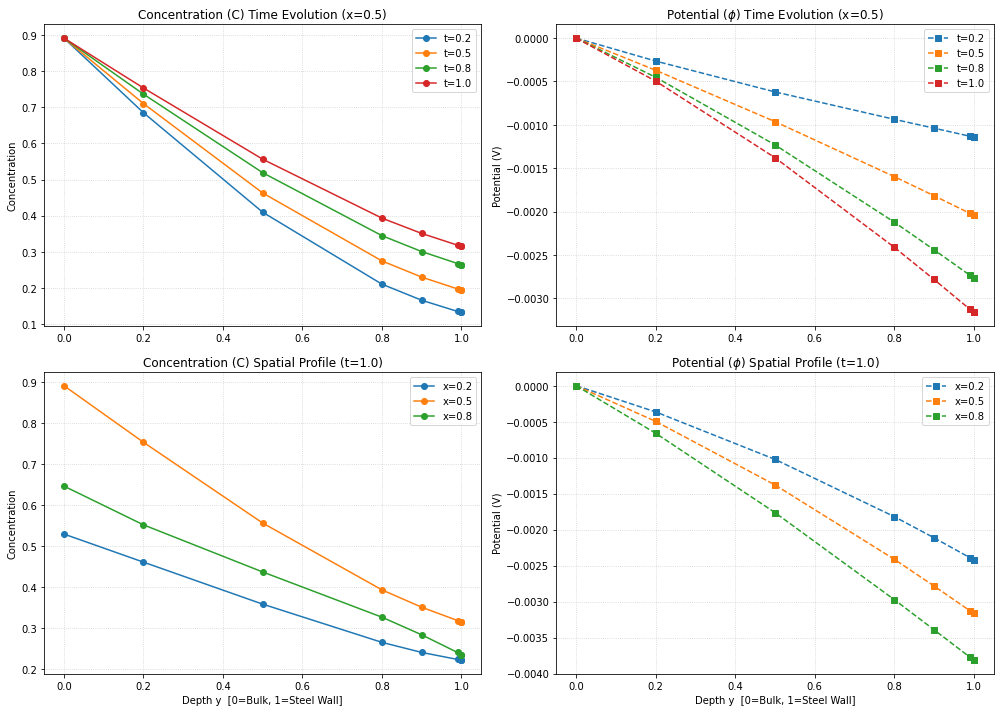


 PINN vs FDM (x-varying sigma, t=1.0)
  C   rel L2 : mean 1.5028e-01   worst 3.0156e-01
  phi rel L2 : mean 2.8168e-01   worst 1.1636e+00
  wall flux  : mean 31.29%   worst 62.82%

  ACROSS samples : spread 141.0% (true 132.5%)  corr +0.956
  ALONG x        : var 0.06849 (true 0.06163, 111%)  corr +0.187

    WT       C L2   flux err  C_wall pred  C_wall true
 0.251 2.6865e-01     41.18%     0.244726     0.255269
 0.364 1.1763e-01     42.34%     0.249932     0.234790
 0.478 1.0665e-01     44.45%     0.219516     0.191893
 0.564 2.7005e-01     32.01%     0.189534     0.158015
 0.644 1.1866e-01     13.83%     0.154723     0.130759
 0.750 2.9031e-01     17.94%     0.107427     0.099412
 0.805 1.4178e-01     27.87%     0.135952     0.118212
 0.856 1.5318e-01     38.60%     0.186088     0.145335


In [12]:
def diagnostic_boundary_scan_vmionet(model, data_tensors, device="cuda"):
    """Probes are given in PHYSICAL y (0=bulk, 1=wall) and converted to the
    model's distance coordinate d = 1 - y before inference."""
    model.eval()
    x_soil, x_fluid, x_meta, _ = [t.to(device) for t in data_tensors]
    soil_single, fluid_single, meta_single = x_soil[0:1], x_fluid[0:1], x_meta[0:1]

    # y=1.0 is the wall; extra probes packed near the wall to resolve the layer
    y_probes = [0.0, 0.2, 0.5, 0.8, 0.9, 0.99, 0.9999, 0.999999, 1.0]

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    
    # ---- SWEEP 1: TIME EVOLUTION (fixed x=0.5) ----
    print(" SWEEP 1: TIME EVOLUTION (Fixed x=0.5)")
    print("=" * 50)
    for t_val in [0.2, 0.5, 0.8, 1.0]:
        print(f"\n--- TIME EVOLUTION: t={t_val}, x=0.5 ---")
        print(f"{'y-coord':<12} | {'C (Pred)':<15} | {'phi (Pred) V':<15}")
        print("-" * 48)

        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                d_val = 1.0 - y_val                      # <-- y -> d conversion
                coord = torch.tensor([[[0.5, d_val, t_val]]],
                                     dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_raw = u_pred[0, 0, 0].item()
                phi_raw = u_pred[0, 0, 1].item()
                C_vals.append(C_raw)
                phi_vals.append(phi_raw)
                print(f"{y_val:<12.6f} | {C_raw:<15.8e} | {phi_raw:<15.8e}")
        print("-" * 48)

        axs[0, 0].plot(y_probes, C_vals, marker='o', label=f"t={t_val}")
        axs[0, 1].plot(y_probes, phi_vals, marker='s', linestyle='--', label=f"t={t_val}")

    axs[0, 0].set_title('Concentration (C) Time Evolution (x=0.5)')
    axs[0, 0].set_ylabel('Concentration')
    axs[0, 1].set_title(r'Potential ($\phi$) Time Evolution (x=0.5)')
    axs[0, 1].set_ylabel('Potential (V)')

    # ---- SWEEP 2: SPATIAL DISTRIBUTION (fixed t=1.0) ----
    print(" SWEEP 2: SPATIAL DISTRIBUTION (Fixed t=1.0)")
    print("=" * 50)
    for x_val in [0.2, 0.5, 0.8]:
        print(f"\n--- SPATIAL DISTRIBUTION: t=1.0, x={x_val} ---")
        print(f"{'y-coord':<12} | {'C (Pred)':<15} | {'phi (Pred) V':<15}")
        print("-" * 48)

        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                d_val = 1.0 - y_val                      # <-- y -> d conversion
                coord = torch.tensor([[[x_val, d_val, 1.0]]],
                                     dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_raw = u_pred[0, 0, 0].item()
                phi_raw = u_pred[0, 0, 1].item()
                C_vals.append(C_raw)
                phi_vals.append(phi_raw)
                print(f"{y_val:<12.6f} | {C_raw:<15.8e} | {phi_raw:<15.8e}")
        print("-" * 48)

        axs[1, 0].plot(y_probes, C_vals, marker='o', label=f"x={x_val}")
        axs[1, 1].plot(y_probes, phi_vals, marker='s', linestyle='--', label=f"x={x_val}")

    axs[1, 0].set_title('Concentration (C) Spatial Profile (t=1.0)')
    axs[1, 0].set_xlabel('Depth y  [0=Bulk, 1=Steel Wall]')
    axs[1, 0].set_ylabel('Concentration')
    axs[1, 1].set_title(r'Potential ($\phi$) Spatial Profile (t=1.0)')
    axs[1, 1].set_xlabel('Depth y  [0=Bulk, 1=Steel Wall]')
    axs[1, 1].set_ylabel('Potential (V)')

    for ax in axs.flat:
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.show()
    
def validate_pinn_vs_fdm(model, data_tensors, fdm_C, fdm_phi, fdm_x, fdm_y,
                         device="cuda", n_samples=64):
    """Validate against the x-varying FDM ground truth.

    No closed form exists once sigma varies with x, so the FDM (verified to
    1e-11 in the uniform limit) is the reference.

    Reports four things, in increasing order of what they actually tell you:
      C/phi rel L2   -- pointwise fit
      wall flux      -- the corrosion-rate quantity; well-conditioned, unlike
                        C_wall which is a 1-minus-1 cancellation (~6 digits lost)
      ACROSS-sample  -- does the model tell environments apart, or has it
                        learned the batch mean? A model at the mean scores
                        well on the two above while being useless as an operator
      ALONG-x        -- does it resolve sigma(x)? This is the whole point of
                        the x-varying formulation; everything else can look
                        fine while this is zero
    """    
    b_soil, b_fluid, b_meta, raw_meta = [t[:n_samples].to(device) for t in data_tensors]

    Nx, Ny = len(fdm_x), len(fdm_y)
    X, Y = torch.meshgrid(fdm_x, fdm_y, indexing="ij")
    coords = torch.stack([X.flatten(), 1.0 - Y.flatten(),
                          torch.ones_like(X.flatten())], dim=-1)   # d = 1 - y
    coords = coords.unsqueeze(0).expand(n_samples, Nx * Ny, 3)

    model.eval()
    with torch.no_grad():
        u = model(b_soil, b_fluid, b_meta, coords)
        C_p = u[..., 0].view(n_samples, Nx, Ny)
        phi_p = u[..., 1].view(n_samples, Nx, Ny)

    C_t, phi_t = fdm_C[:n_samples], fdm_phi[:n_samples]

    C_err = (C_p - C_t).flatten(1).norm(dim=1) / C_t.flatten(1).norm(dim=1)
    phi_err = (phi_p - phi_t).flatten(1).norm(dim=1) / phi_t.flatten(1).norm(dim=1)

    flux_p = (C_p[:, :, -1] - C_p[:, :, -2]) / (fdm_y[-1] - fdm_y[-2])
    flux_t = (C_t[:, :, -1] - C_t[:, :, -2]) / (fdm_y[-1] - fdm_y[-2])
    flux_err = ((flux_p - flux_t).abs() / flux_t.abs().clamp_min(1e-12)).mean(dim=1)

    cw_p, cw_t = C_p[:, :, -1], C_t[:, :, -1]                      # [B, Nx]

    op_corr = np.corrcoef(cw_p.mean(1).cpu().numpy(),
                          cw_t.mean(1).cpu().numpy())[0, 1]
    # normalize spread by the TRUE mean -- using the predicted mean explodes
    # this metric when predictions collapse toward zero (gave a bogus 3305%)
    ref = cw_t.mean().item()
    spread_p = 100 * (cw_p.mean(1).max() - cw_p.mean(1).min()).item() / ref
    spread_t = 100 * (cw_t.mean(1).max() - cw_t.mean(1).min()).item() / ref

    x_var_p = (cw_p.max(1).values - cw_p.min(1).values).mean().item()
    x_var_t = (cw_t.max(1).values - cw_t.min(1).values).mean().item()
    x_corr = float(np.mean([np.corrcoef(cw_p[i].cpu().numpy(),
                                        cw_t[i].cpu().numpy())[0, 1]
                            for i in range(n_samples)]))

    print("\n" + "=" * 62)
    print(" PINN vs FDM (x-varying sigma, t=1.0)")
    print("=" * 62)
    print(f"  C   rel L2 : mean {C_err.mean():.4e}   worst {C_err.max():.4e}")
    print(f"  phi rel L2 : mean {phi_err.mean():.4e}   worst {phi_err.max():.4e}")
    print(f"  wall flux  : mean {flux_err.mean()*100:.2f}%   worst {flux_err.max()*100:.2f}%")
    print(f"\n  ACROSS samples : spread {spread_p:.1f}% (true {spread_t:.1f}%)  corr {op_corr:+.3f}")
    print(f"  ALONG x        : var {x_var_p:.5f} (true {x_var_t:.5f}, "
          f"{100*x_var_p/x_var_t:.0f}%)  corr {x_corr:+.3f}")
    if x_var_p > 3 * x_var_t:
        print("  ** x-variation far exceeds truth -- fitting noise, not sigma(x) **")
    elif x_var_p < 0.1 * x_var_t:
        print("  ** nearly flat in x -- the sigma(x) signal is not being learned **")

    print(f"\n{'WT':>6} {'C L2':>10} {'flux err':>10} {'C_wall pred':>12} {'C_wall true':>12}")
    for i in torch.argsort(raw_meta[:, 0])[:: max(1, n_samples // 8)]:
        print(f"{raw_meta[i,0].item():>6.3f} {C_err[i].item():>10.4e} "
              f"{flux_err[i].item()*100:>9.2f}% {cw_p[i].mean().item():>12.6f} "
              f"{cw_t[i].mean().item():>12.6f}")

    return dict(C_l2=C_err.mean().item(), phi_l2=phi_err.mean().item(),
                flux_err=flux_err.mean().item(), op_corr=float(op_corr),
                x_corr=x_corr, x_var_ratio=x_var_p / x_var_t)

print("\n" + "#" * 62)
print("#  ADAM BASELINE (pre-L-BFGS)")
print("#" * 62)

diagnostic_boundary_scan_vmionet(trained_vmionet, dataset_tensors, execution_device)
metrics_adam = validate_pinn_vs_fdm(trained_vmionet, dataset_tensors,
                                    fdm_C, fdm_phi, fdm_x, fdm_y, execution_device)

## L-BFGS Phase

In [13]:
import copy
import gc
import logging
import torch
import torch.optim as optim

# Clear cached CUDA memory prior to allocating L-BFGS graphs
gc.collect()
torch.cuda.empty_cache()


def run_lbfgs_phase(
    model,
    data_tensors,
    quad_engine,
    test_engine,
    phys_params,
    fdm_C,
    fdm_phi,
    fdm_x,
    fdm_y,
    device="cuda",
    steps=100,
    lbfgs_batch=200,
    history_size=20,
):
    model.eval()
    # FIXED subset -- deterministic across closure calls, which strong-Wolfe
    # requires. Reduced from 700 to 200 to fit full autograd computational 
    # graphs in GPU memory during L-BFGS history tracking.
    lbfgs_batch = min(lbfgs_batch, data_tensors[0].shape[0])
    batch_data = [t[:lbfgs_batch].to(device) for t in data_tensors]
    quad_engine = [t.to(device) for t in quad_engine]
    test_engine = [t.to(device) for t in test_engine]

    # leading slice -> batch position i is FDM row i
    anchor_idx = torch.arange(lbfgs_batch, device=device)

    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.1,
        max_iter=steps,
        max_eval=steps,
        tolerance_grad=1e-7,
        tolerance_change=1e-6,
        history_size=history_size,
        line_search_fn="strong_wolfe",
    )
    closure_evals = 0
    logging.info(
        f"Phase D: L-BFGS ({steps} steps, batch={lbfgs_batch},"
        f" history={history_size})"
    )

    def closure():
        nonlocal closure_evals
        closure_evals += 1
        optimizer.zero_grad(set_to_none=True)
        torch.manual_seed(42)  # stationary landscape for strong-Wolfe

        # Unpack 4 returned values from compute_weak_loss_split
        res_C, res_phi, bounds, loss_x_smooth = compute_weak_loss_split(
            model,
            batch_data,
            quad_engine,
            test_engine,
            phys_params,
            N_t=5,
            device=device,
        )
        dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
            model, batch_data, N_samples=50, device=device
        )
        loss_anchor = compute_anchor_loss_fdm(
            model,
            anchor_idx,
            batch_data,
            fdm_C,
            fdm_phi,
            fdm_x,
            fdm_y,
            phys_params,
            n_pts=4,
            device=device,
        )

        # SAME weights as the Adam phase. A different objective here would pull
        # toward a different minimum and read as "L-BFGS didn't help".
        # dir_C/dir_phi are identically zero (ansatz enforces them) -- omitted.
        loss_mass = (
            W_RES_C * res_C
            + W_SMOOTH * loss_x_smooth  # MUST be present in L-BFGS closure
            + W_IC_C * ic_C
            + W_ENDS_C * ends_C
            + W_BOUNDS * bounds
        )

        loss_charge = W_RES_PHI * res_phi + W_ENDS_PHI * ends_phi
        total_loss = loss_mass + loss_charge + W_ANCHOR * loss_anchor

        total_loss.backward()
        return total_loss

    optimizer.step(closure)
    logging.info(f"L-BFGS Complete. Total Closure Evals: {closure_evals}")
    return model


# deep copy so trained_vmionet stays as the Adam baseline for comparison
model_lbfgs = copy.deepcopy(trained_vmionet)

model_lbfgs = run_lbfgs_phase(
    model=model_lbfgs,
    data_tensors=dataset_tensors,
    quad_engine=quad_tensors,
    test_engine=test_tensors,
    phys_params=PHYSICS_PARAMS,
    fdm_C=fdm_C,
    fdm_phi=fdm_phi,
    fdm_x=fdm_x,
    fdm_y=fdm_y,
    device=execution_device,
    steps=100,  # Reduced from 250 to prevent over-refinement of spatial wiggles
    lbfgs_batch=200,  # Deterministic 200-sample slice to avoid VRAM OOM
)

2026-08-20 12:43:10,586 | INFO | Phase D: L-BFGS (100 steps, batch=200, history=20)
2026-08-20 12:43:25,722 | INFO | L-BFGS Complete. Total Closure Evals: 101


## Audit Post L-BFGS


##############################################################
#  AFTER L-BFGS
##############################################################
 SWEEP 1: TIME EVOLUTION (Fixed x=0.5)

--- TIME EVOLUTION: t=0.2, x=0.5 ---
y-coord      | C (Pred)        | phi (Pred) V   
------------------------------------------------
0.000000     | 8.91498983e-01  | 0.00000000e+00 
0.200000     | 6.84493482e-01  | -5.71465585e-04
0.500000     | 3.95145953e-01  | -1.37096178e-03
0.800000     | 1.73599184e-01  | -2.09082616e-03
0.900000     | 1.20410800e-01  | -2.31821858e-03
0.990000     | 8.08501244e-02  | -2.52074492e-03
0.999900     | 7.69258738e-02  | -2.54299399e-03
0.999999     | 7.68870711e-02  | -2.54321191e-03
1.000000     | 7.68866539e-02  | -2.54321564e-03
------------------------------------------------

--- TIME EVOLUTION: t=0.5, x=0.5 ---
y-coord      | C (Pred)        | phi (Pred) V   
------------------------------------------------
0.000000     | 8.91498983e-01  | 0.00000000e+00 
0.20000

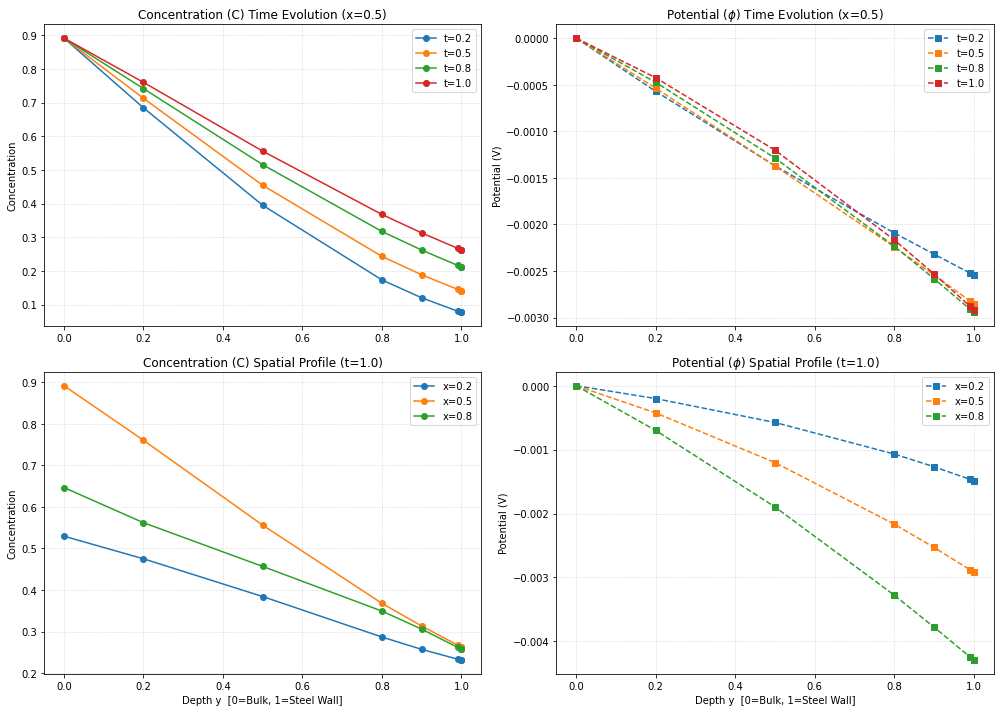


 PINN vs FDM (x-varying sigma, t=1.0)
  C   rel L2 : mean 1.6008e-01   worst 3.1123e-01
  phi rel L2 : mean 3.5844e-01   worst 1.2712e+00
  wall flux  : mean 26.48%   worst 60.62%

  ACROSS samples : spread 152.4% (true 132.5%)  corr +0.941
  ALONG x        : var 0.05774 (true 0.06163, 94%)  corr +0.193

    WT       C L2   flux err  C_wall pred  C_wall true
 0.251 2.6164e-01     39.86%     0.243482     0.255269
 0.364 1.1329e-01     28.64%     0.249774     0.234790
 0.478 1.1815e-01     35.30%     0.228250     0.191893
 0.564 2.5940e-01     18.77%     0.188734     0.158015
 0.644 1.2161e-01      9.30%     0.156246     0.130759
 0.750 3.1123e-01     23.57%     0.104011     0.099412
 0.805 1.4806e-01     20.10%     0.141745     0.118212
 0.856 1.6410e-01     33.49%     0.195520     0.145335

 ADAM vs L-BFGS
metric                 Adam       L-BFGS     change
C_l2                 0.1503       0.1601      1.07x
phi_l2               0.2817       0.3584      1.27x
flux_err             0.31

In [14]:
print("\n" + "#" * 62)
print("#  AFTER L-BFGS")
print("#" * 62)

diagnostic_boundary_scan_vmionet(model_lbfgs, dataset_tensors, execution_device)
metrics_lbfgs = validate_pinn_vs_fdm(model_lbfgs, dataset_tensors,
                                     fdm_C, fdm_phi, fdm_x, fdm_y, execution_device)

print("\n" + "=" * 62)
print(" ADAM vs L-BFGS")
print("=" * 62)
print(f"{'metric':<14} {'Adam':>12} {'L-BFGS':>12} {'change':>10}")
for k in ["C_l2", "phi_l2", "flux_err", "op_corr", "x_corr", "x_var_ratio"]:
    a, b = metrics_adam[k], metrics_lbfgs[k]
    if k in ("op_corr", "x_corr"):          # higher is better, additive
        note = f"{b-a:+.3f}"
    else:                                    # lower is better, multiplicative
        note = f"{b/a:.2f}x" if a != 0 else "n/a"
    print(f"{k:<14} {a:>12.4f} {b:>12.4f} {note:>10}")

## Tests

In [15]:
# Re-derive sample counts dynamically from loaded tensors
N_TRAIN = dataset_tensors[0].shape[0]
N_HOLD = holdout_tensors[0].shape[0]

# =============================================================================
# EVALUATION & VALIDATION
# =============================================================================
print("#" * 62)
print("#  TRAINING SET (seen by optimizer)")
print("#" * 62)
m_train = validate_pinn_vs_fdm(
    model_lbfgs, 
    dataset_tensors, 
    fdm_C, 
    fdm_phi, 
    fdm_x, 
    fdm_y,
    execution_device, 
    n_samples=N_TRAIN
)

print("\n" + "#" * 62)
print("#  HELD-OUT SET (never seen)")
print("#" * 62)
m_hold = validate_pinn_vs_fdm(
    model_lbfgs, 
    holdout_tensors, 
    fdm_C_ho, 
    fdm_phi_ho, 
    fdm_x, 
    fdm_y,
    execution_device, 
    n_samples=N_HOLD
)

print("\n" + "=" * 62)
print(" GENERALIZATION GAP")
print("=" * 62)
print(f"{'metric':<16} {'train':>10} {'held-out':>10} {'gap':>10}")
for k in ["C_l2", "phi_l2", "flux_err", "op_corr", "x_corr", "x_var_ratio"]:
    a, b = m_train[k], m_hold[k]
    gap = f"{b-a:+.3f}" if k in ("op_corr", "x_corr") else \
          (f"{(b-a)/a*100:+.1f}%" if a != 0 else "n/a")
    print(f"{k:<16} {a:>10.4f} {b:>10.4f} {gap:>10}")

##############################################################
#  TRAINING SET (seen by optimizer)
##############################################################

 PINN vs FDM (x-varying sigma, t=1.0)
  C   rel L2 : mean 1.5511e-01   worst 4.4705e-01
  phi rel L2 : mean 3.6060e-01   worst 1.7346e+00
  wall flux  : mean 25.91%   worst 61.61%

  ACROSS samples : spread 179.3% (true 179.8%)  corr +0.952
  ALONG x        : var 0.06047 (true 0.05869, 103%)  corr +0.174

    WT       C L2   flux err  C_wall pred  C_wall true
 0.250 1.6749e-01     51.09%     0.269925     0.258907
 0.353 1.1183e-01     21.55%     0.238654     0.216139
 0.461 2.0366e-01     30.50%     0.174497     0.135138
 0.542 1.6563e-01     18.60%     0.175106     0.140662
 0.627 2.9337e-01     37.89%     0.157347     0.117468
 0.717 2.5226e-01     20.30%     0.131063     0.104758
 0.790 1.4071e-01     14.90%     0.124897     0.109029
 0.883 1.5572e-01     26.40%     0.176313     0.133795
 0.995 2.0031e-01     34.37%     0.

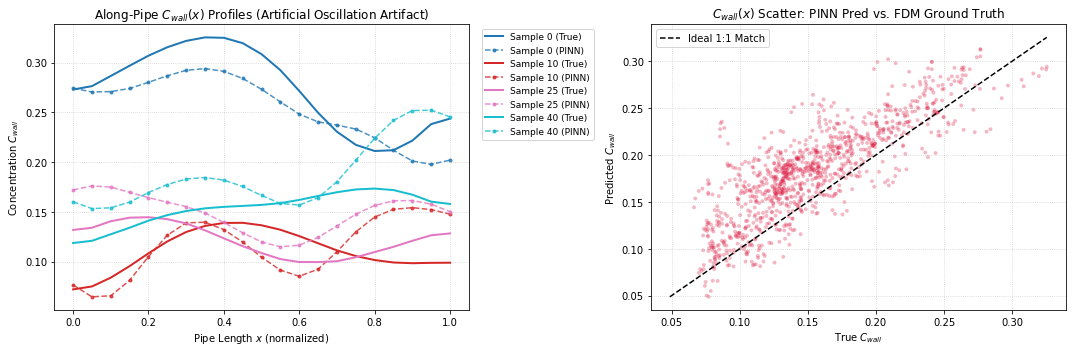

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_x_variance_defect(model, holdout_tensors, fdm_C_ho, fdm_x, device="cuda", sample_indices=[0, 10, 25, 40]):
    model.eval()
    b_soil, b_fluid, b_meta, _ = [t.to(device) for t in holdout_tensors]
    
    Nx = len(fdm_x)
    # Wall coordinate: y = 1.0 -> d = 1 - y = 0.0, at t = 1.0
    wall_coords = torch.stack([
        fdm_x, 
        torch.zeros_like(fdm_x), 
        torch.ones_like(fdm_x)
    ], dim=-1).unsqueeze(0)  # [1, Nx, 3]
    
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    
    # -------------------------------------------------------------------------
    # Panel 1: Along-pipe Wall Concentration Profile C_wall(x)
    # -------------------------------------------------------------------------
    colors = plt.cm.tab10(np.linspace(0, 1, len(sample_indices)))
    
    for idx_num, sample_idx in enumerate(sample_indices):
        soil_i = b_soil[sample_idx:sample_idx+1]
        fluid_i = b_fluid[sample_idx:sample_idx+1]
        meta_i = b_meta[sample_idx:sample_idx+1]
        
        with torch.no_grad():
            u_pred = model(soil_i, fluid_i, meta_i, wall_coords)
            c_pred_x = u_pred[0, :, 0].cpu().numpy()
            
        c_true_x = fdm_C_ho[sample_idx, :, -1].cpu().numpy()
        x_axis = fdm_x.cpu().numpy()
        
        c = colors[idx_num]
        axs[0].plot(x_axis, c_true_x, label=f'Sample {sample_idx} (True)', color=c, linewidth=2.0)
        axs[0].plot(x_axis, c_pred_x, label=f'Sample {sample_idx} (PINN)', color=c, linestyle='--', marker='o', markersize=3, alpha=0.8)
        
    axs[0].set_title(r"Along-Pipe $C_{wall}(x)$ Profiles (Artificial Oscillation Artifact)")
    axs[0].set_xlabel("Pipe Length $x$ (normalized)")
    axs[0].set_ylabel(r"Concentration $C_{wall}$")
    axs[0].grid(True, linestyle=':', alpha=0.6)
    axs[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    
    # -------------------------------------------------------------------------
    # Panel 2: Scatter Plot Across All Held-Out Wall Nodes
    # -------------------------------------------------------------------------
    N_hold = b_soil.shape[0]
    wall_coords_all = wall_coords.expand(N_hold, Nx, 3)
    
    with torch.no_grad():
        u_all = model(b_soil, b_fluid, b_meta, wall_coords_all)
        c_pred_all = u_all[..., 0].cpu().numpy().flatten()
        
    c_true_all = fdm_C_ho[:, :, -1].cpu().numpy().flatten()
    
    axs[1].scatter(c_true_all, c_pred_all, alpha=0.3, color='crimson', edgecolor='none', s=15)
    
    # 1:1 Reference Line
    min_val = min(c_true_all.min(), c_pred_all.min())
    max_val = max(c_true_all.max(), c_pred_all.max())
    axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Ideal 1:1 Match')
    
    axs[1].set_title(r"$C_{wall}(x)$ Scatter: PINN Pred vs. FDM Ground Truth")
    axs[1].set_xlabel(r"True $C_{wall}$")
    axs[1].set_ylabel(r"Predicted $C_{wall}$")
    axs[1].grid(True, linestyle=':', alpha=0.6)
    axs[1].legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Run visualization on held-out set
visualize_x_variance_defect(model_lbfgs, holdout_tensors, fdm_C_ho, fdm_x, device=execution_device)